# Decision Matrix

This notebook converts the broad atlas into a decision aid for research planning.

Corpus anchors: `QRE2`, `QRE4`, `LBM14`, `CAR7`, `IO4`, `IO5`, `IO7`, `IO8`, `PRIM5`, `PRIM6`, `PRIM8`, `PRIM14`, `PRIM15`, `PRIM16`.

Compact object: objective-by-tool suitability scores for choosing future demos and route-support work.


tooling atlas output directory: .cache\tooling_atlas


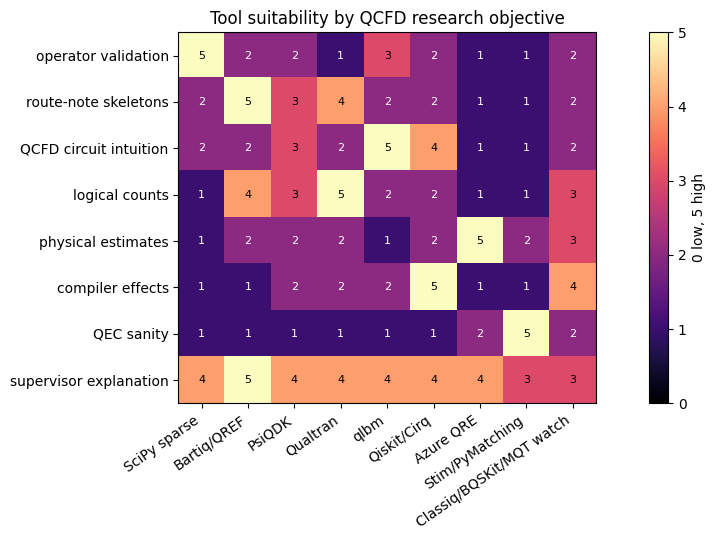

{
  "operator validation": "SciPy sparse",
  "route-note skeletons": "Bartiq/QREF",
  "QCFD circuit intuition": "qlbm",
  "logical counts": "Qualtran",
  "physical estimates": "Azure QRE",
  "compiler effects": "Qiskit/Cirq",
  "QEC sanity": "Stim/PyMatching",
  "supervisor explanation": "Bartiq/QREF"
}
falsifiable check: every objective has at least one strong candidate score


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

objectives = [
    'operator validation',
    'route-note skeletons',
    'QCFD circuit intuition',
    'logical counts',
    'physical estimates',
    'compiler effects',
    'QEC sanity',
    'supervisor explanation',
]
tools = ['SciPy sparse', 'Bartiq/QREF', 'PsiQDK', 'Qualtran', 'qlbm', 'Qiskit/Cirq', 'Azure QRE', 'Stim/PyMatching', 'Classiq/BQSKit/MQT watch']
scores = np.array([
    [5, 2, 2, 1, 3, 2, 1, 1, 2],
    [2, 5, 3, 4, 2, 2, 1, 1, 2],
    [2, 2, 3, 2, 5, 4, 1, 1, 2],
    [1, 4, 3, 5, 2, 2, 1, 1, 3],
    [1, 2, 2, 2, 1, 2, 5, 2, 3],
    [1, 1, 2, 2, 2, 5, 1, 1, 4],
    [1, 1, 1, 1, 1, 1, 2, 5, 2],
    [4, 5, 4, 4, 4, 4, 4, 3, 3],
])

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(scores, vmin=0, vmax=5, cmap='magma')
ax.set_xticks(range(len(tools)), tools, rotation=35, ha='right')
ax.set_yticks(range(len(objectives)), objectives)
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(j, i, str(scores[i, j]), ha='center', va='center', color='white' if scores[i, j] < 3 else 'black', fontsize=8)
ax.set_title('Tool suitability by QCFD research objective')
fig.colorbar(im, ax=ax, label='0 low, 5 high')
plt.tight_layout()
plt.show()

best = {objective: tools[int(np.argmax(scores[i]))] for i, objective in enumerate(objectives)}
print(json.dumps(best, indent=2))
assert all(scores[i].max() >= 4 for i in range(scores.shape[0]))
print('falsifiable check: every objective has at least one strong candidate score')


## What This Cannot Prove

The matrix is a planning aid, not a final tool choice. Scores should change after live sandbox evidence, route-note extraction, install friction, and supervisor feedback.
